### Linear Regression from Scratch

---

#### 🎯 Goal
- Understand the intuition behind linear regression  
- Build a strong conceptual foundation

In [37]:
import numpy as np
import matplotlib.pyplot as plt

In [38]:
def predict(m, x, c):
    return  m * x + c;

print(f'Test 1: {predict(m=2,x=3, c=1)}')

print(f'Test 2: {predict(m=5, x=0, c=10)}')

x_arr = np.array([0, 1, 2, 3, 4])

print(f'Test 3: {predict(m=2, x=x_arr, c =1)}')



Test 1: 7
Test 2: 10
Test 3: [1 3 5 7 9]


In [39]:


# Reproducibility: same random numbers every run
np.random.seed(42)

# 100 random input values from a standard normal distribution (mean=0, std=1)
x = np.random.randn(100)

# Random noise — same shape as x
noise = np.random.randn(100)

# True relationship: y = 2x + 1 + noise
TRUE_W = 2.0
TRUE_B = 1.0
y = TRUE_W * x + TRUE_B + noise

# Quick sanity check
print("x shape:", x.shape)        # (100,)
print("y shape:", y.shape)        # (100,)
print("First 5 x values:", x[:5])
print("First 5 y values:", y[:5])

x shape: (100,)
y shape: (100,)
First 5 x values: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
First 5 y values: [0.57805756 0.30282607 1.95266256 3.24378244 0.37040754]


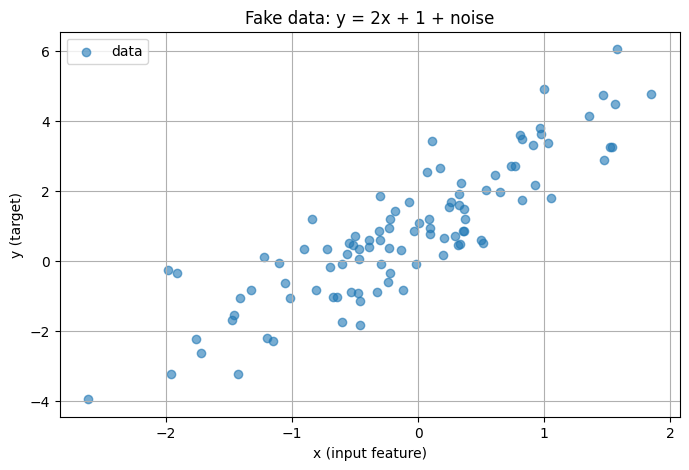

In [40]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, label="data")
plt.title("Fake data: y = 2x + 1 + noise")
plt.xlabel("x (input feature)")
plt.ylabel("y (target)")
plt.grid(True)
plt.legend()
plt.show()

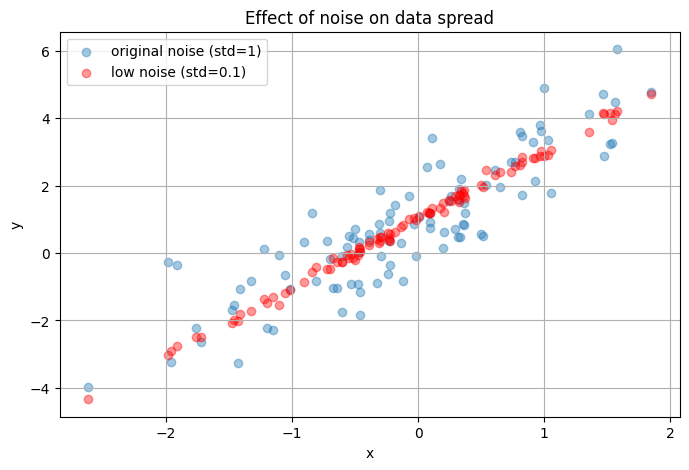

In [41]:
# What happens if we make the noise smaller?
y_low_noise = TRUE_W * x + TRUE_B + 0.1 * np.random.randn(100)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.4, label="original noise (std=1)")
plt.scatter(x, y_low_noise, alpha=0.4, color='red', label="low noise (std=0.1)")
plt.title("Effect of noise on data spread")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

### Measuring how wrong the line is — MSE

For each data point, the **residual** is how far the prediction is from the truth:

$$\text{residual}_i = y_i - \hat{y}_i$$

To summarize all 100 residuals into one number, we use **Mean Squared Error**:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Why square?**
1. Negatives don't cancel positives
2. Big errors are punished more than small ones
3. Math behind gradient descent is cleaner

**Lower MSE = better line.** A perfect fit has MSE = 0.

In [42]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# Test 1: perfect prediction → MSE should be 0
y_t = np.array([1.0, 2.0, 3.0])
y_p = np.array([1.0, 2.0, 3.0])

print(f'Mean Squared Error: {mse(y_true=y_t, y_pred=y_p)}')


# Test 2: off by exactly 1 each → MSE should be 1
y_p_off1 = np.array([2.0, 3.0, 4.0])
print(f'Mean Squared Error: {mse(y_true=y_t, y_pred=y_p_off1)}')

# Test 3: one point off by 2, rest perfect
y_p_bad = np.array([1.0, 2.0, 5.0])
print(f'Mean Squared Error : {mse(y_true=y_t,y_pred=y_p_bad)}')


# Test 4: negative residuals don't cancel positive
y_t_2 = np.array([0.0, 0.0])
y_p_2 = np.array([2.0, -2.0])
print(f'Mean Squared Error : {mse(y_true=y_t_2, y_pred=y_p_2)}')

Mean Squared Error: 0.0
Mean Squared Error: 1.0
Mean Squared Error : 1.3333333333333333
Mean Squared Error : 4.0


In [43]:
# Now try a bad guess
y_pred_bad = 0.5 * x + 0.0
print(f"MSE with w=0.5, b=0.0:           {mse(y, y_pred=y_pred_bad):.4f}")

# And a worse guess
y_pred_worse = -1.0 * x + 5.0
print(f"MSE with w=-1.0, b=5.0:          {mse(y_true=y, y_pred=y_pred_worse):.4f}")

MSE with w=0.5, b=0.0:           3.1375
MSE with w=-1.0, b=5.0:          25.9448


## Reflection — what I learned about MSE
- The lowest achievable MSE for this dataset is 1, std~1, the is what we have added
- Squaring the residual make punish the error badly
- Thumb rule, the lower the MSE, better it will be

y=2x+1+noise
y=mx+b
mse(y_true,y_pred)


## Eyeball-fit: manually guess (m, c) and calculate mse


In [50]:
guess = [
    (1.0 , 0.0),
    (2.0,1.0),
    (3.0,-1.0)
]
print(f"{'w':>6} {'b':>6} {'MSE':>10}")
print("-" * 26)
for m_g, c_g in guess:
    y_pred = m_g * x + c_g
    mean_square_error = mse(y_true=y, y_pred=y_pred)
    print(f"{m_g:>6.2f} {c_g:>6.2f} {mean_square_error:>10.4f}")

     w      b        MSE
--------------------------
  1.00   0.00     2.3265
  2.00   1.00     0.9009
  3.00  -1.00     6.4714


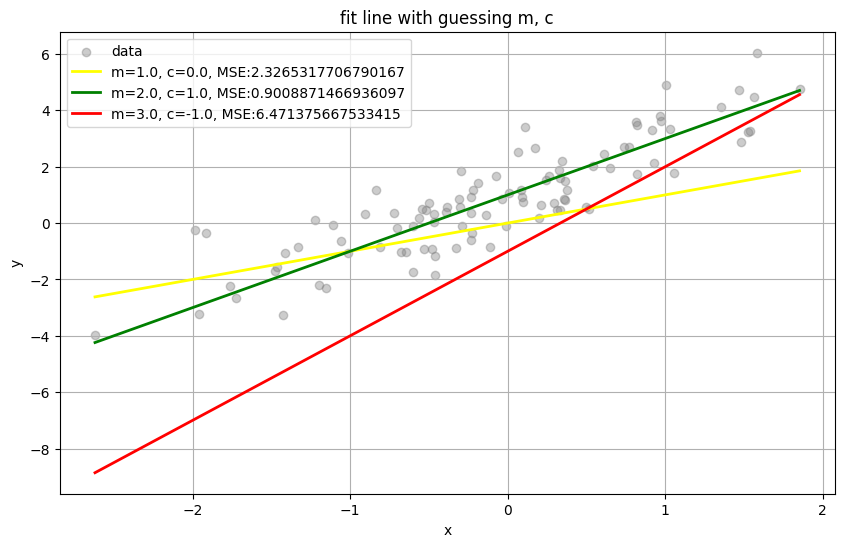

In [69]:
plt.figure(figsize=(10, 6))
plt.scatter(x=x, y=y, alpha=0.4, label='data', color='grey')

x_sorted =  np.sort(x)
colors = ['yellow', 'green', 'red']

for (m_g, c_g), color in zip(guess, colors):
    y_line = m_g * x_sorted + c_g
    mean_square_error = mse(y_true=y, y_pred=m_g * x + c_g)
    plt.plot(x_sorted, y_line, label=f'm={m_g}, c={c_g}, MSE:{mean_square_error}', color=color, linewidth=2)
    
plt.title('fit line with guessing m, c')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()


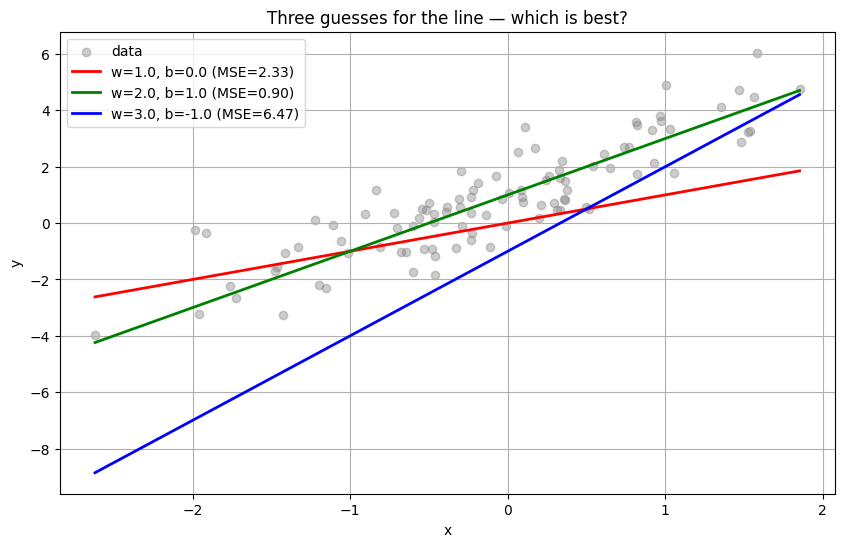

In [55]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.4, label="data", color='gray')

# Sort x so the line plots cleanly
x_sorted = np.sort(x)

colors = ['red', 'green', 'blue']
for (w_g, b_g), color in zip(guess, colors):
    y_line = w_g * x_sorted + b_g
    loss = mse(y, w_g * x + b_g)
    plt.plot(x_sorted, y_line, color=color, linewidth=2,
             label=f"w={w_g}, b={b_g} (MSE={loss:.2f})")

plt.title("Three guesses for the line — which is best?")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

In [100]:
my_guesses = [
    (0.8, 0.2),   # fill in
    (0.7, 0.5),
    (1.2, 1.49),
]

for w_g, b_g in my_guesses:
    y_pred = w_g * x + b_g
    loss = mse(y, y_pred)
    print(f"w={w_g}, b={b_g} → MSE={loss:.4f}")

w=0.8, b=0.2 → MSE=2.2822
w=0.7, b=0.5 → MSE=2.1262
w=1.2, b=1.49 → MSE=1.5392


## Reflection — the bridge to gradient descent

Tonight I:
- written the linear equation y = m * x + c
- Mean square error = np.mean((y_true - y_pred)**2)
- plotted the datapoints(scatter), data line (plot)
- manually guessed 3lines and plotted them

The stage is set for the gradiant decent:
In my terms,
- you have given slope (m) and constant (c), and have mean square error (MSE), to lower the MSE, you are taking the direction called gradient decent, 
- In gradient decent you will be taking small steps to reduce the MSE, in which further you can't reduce.

Why won't manual guessing scale to real ML problems?
- There will be too many parameters in real-dataset in which it is hard for manual guessing.